<a href="https://colab.research.google.com/github/Gadiraju-Harini/2024_Batch/blob/main/Customer_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import zipfile

# Add the leading slash so Colab looks in the root folder
with zipfile.ZipFile('/customer.zip', 'r') as zip_ref:
    zip_ref.extractall('/content')

In [8]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Display basic info and first few rows
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [9]:
import numpy as np

# Convert TotalCharges to numeric, setting empty spaces to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].str.strip(), errors='coerce')

# Fill missing TotalCharges values with 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Drop customerID since it's an arbitrary identifier
df.drop(columns=['customerID'], inplace=True)

# Verify summary info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


/tmp/ipykernel_637/1058726922.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='Set2')


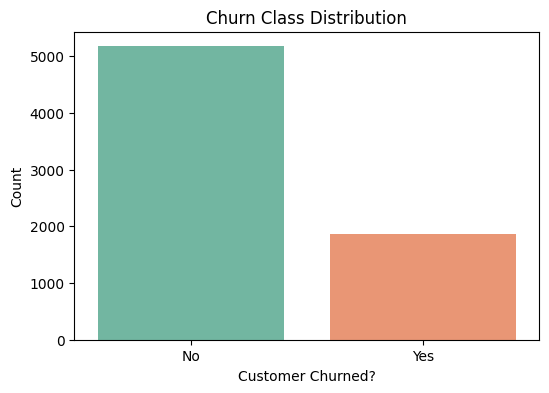

Churn Percentage:
 Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn', palette='Set2')
plt.title('Churn Class Distribution')
plt.xlabel('Customer Churned?')
plt.ylabel('Count')
plt.show()

# Print percentages
print("Churn Percentage:\n", df['Churn'].value_counts(normalize=True) * 100)

In [11]:
# Convert Churn target column ('Yes' -> 1, 'No' -> 0)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Get categorical text columns
cat_cols = df.select_dtypes(include=['object']).columns

# One-Hot Encode remaining text columns
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print("Encoded Shape:", df_encoded.shape)

Encoded Shape: (7043, 31)


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Separate features (X) and target (y)
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

# 80% Train, 20% Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression Model
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
print("=== LOGISTIC REGRESSION SCORE ===")
print("ROC-AUC:", roc_auc_score(y_test, lr_model.predict_proba(X_test_scaled)[:, 1]))

# Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
print("\n=== RANDOM FOREST SCORE ===")
print("ROC-AUC:", roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1]))

=== LOGISTIC REGRESSION SCORE ===
ROC-AUC: 0.841778397788628

=== RANDOM FOREST SCORE ===
ROC-AUC: 0.8253313182980704


/tmp/ipykernel_637/177782256.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10.values, y=top_10.index, palette='RdPu')


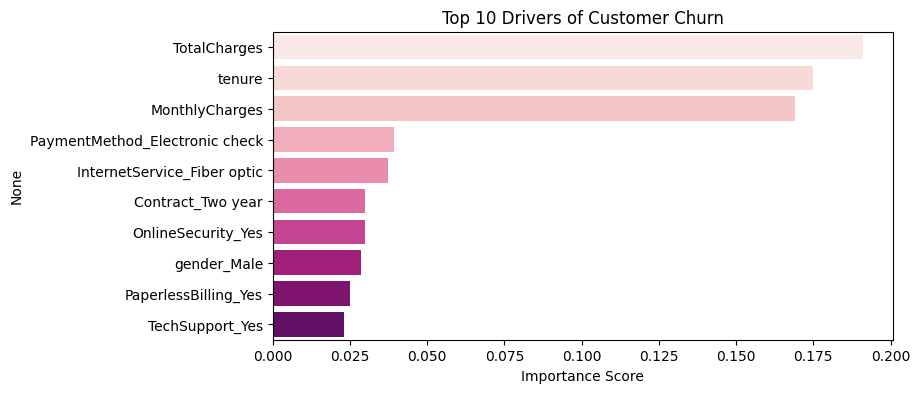

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract top 10 important features from Random Forest
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top_10 = importances.nlargest(10)

plt.figure(figsize=(8, 4))
sns.barplot(x=top_10.values, y=top_10.index, palette='RdPu')
plt.title('Top 10 Drivers of Customer Churn')
plt.xlabel('Importance Score')

plt.show()

In [26]:
import joblib

# Save model and scaler to files
joblib.dump(rf_model, 'churn_rf_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Model saved successfully! Project 1 Complete 🎉")

Model saved successfully! Project 1 Complete 🎉
